2. Time-based Analysis and EDA

2.1 Article counts of different universities over years


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

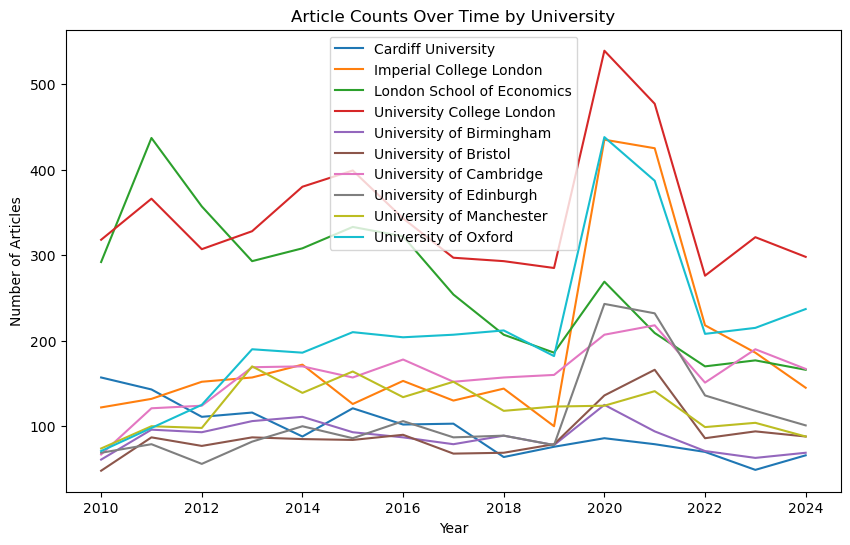

In [9]:
df = pd.read_csv('data/raw/combined_raw.csv')

df['webPublicationDate'] = pd.to_datetime(df['webPublicationDate'])
df['year'] = df['webPublicationDate'].dt.year

counts = df.groupby(['year', 'university']).size().reset_index(name='article_count')

plt.figure(figsize=(10, 6))

for uni in counts['university'].unique():
    subset = counts[counts['university'] == uni]
    plt.plot(subset['year'], subset['article_count'], label=uni)

plt.legend()
plt.title("Article Counts Over Time by University")
plt.xlabel("Year")
plt.ylabel("Number of Articles")

plt.show()

These line charts demonstrate the article counts of 10 universities, and we can observe the changes and trends over time. 

The first observed pattern is a 'universal peak' of article counts around 2020, when most of the selected universities were mentioned in the media more frequently compared to other years. One major event that happened in 2020 was the breakout of COVID-19, which influenced the majority of the population in the UK, as well as university students. Due to COVID-19, universities had to adjust their teaching mode, i.e., switching to online classes. Together with other associated adjustments, COVID-19 could be a reasonable explanation for this universal increase.

The second observation is that UCL has overall the largest article counts over these years. This is very reasonable, as UCL is one of the most famous universities in the UK, and its size is comparatively larger than the others in this chart, i.e., LSE, Oxford, and Imperial.

Third, we find that some universities display different trends in terms of their article counts. For example, LSE shows a downward trend, and Imperial College shows an upward trend. 

In other times, the article counts of universities almost follow a similar trend. This implies the frequency of news and reports on universities is affected by larger-scale social issues, like COVID-19.

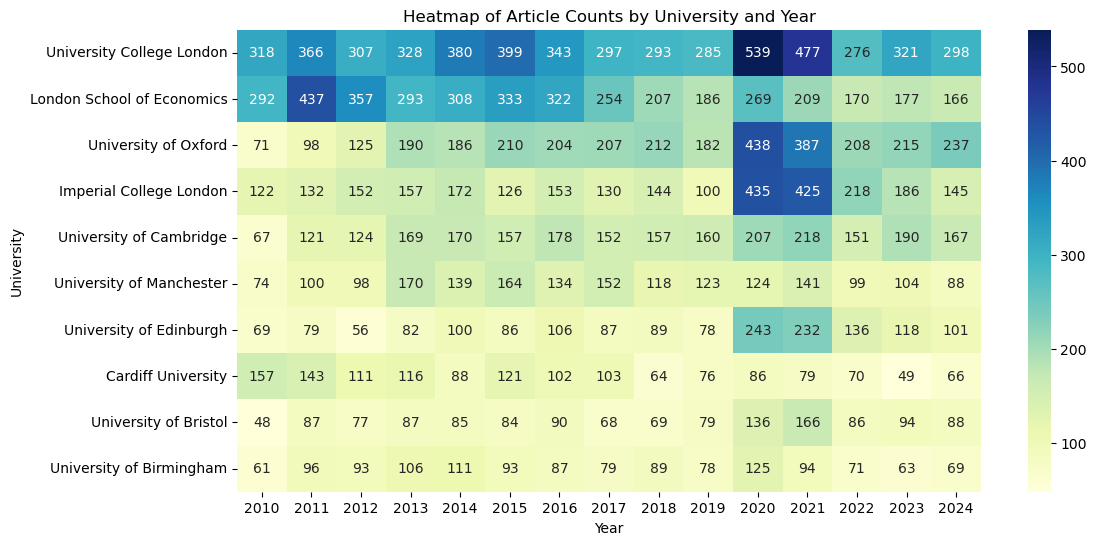

In [10]:
pivot = counts.pivot(
    index='university', 
    columns='year', 
    values='article_count'
).fillna(0)

pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    pivot, 
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Heatmap of Article Counts by University and Year")
plt.xlabel("Year")
plt.ylabel("University")

plt.show()

This heatmap demonstrates the same information from the line chart, but tells more explicitly about the comparative number of articles related to different universities in different years. From this chart, we can see that there are more articles related to universities in the years 2020 and 2021; and over this 15-year time interval, the top 5 UK universities ('top' in terms of general reputation) have more media coverage than others.

2.2 Further Analysis -- Overlay the major events on the time series

From 2010 to 2024, the United Kingdom experienced a period under the Conservative-led government characterized by "austerity" spending cuts, the 2016 Brexit, a lasting global pandemic, political instability, economic slowdown, recovery, etc. Here, we list some major issues with social, political, and economic impact during this period.

In the previous section, we found the notable changes during the COVID-19 breakout. However, besides this finding, we would like to see what other impact social events had on the media coverage of universities during 2010-2014. We start it with listing the major events with a timeline.

2010–2015: Coalition and Austerity
- 2010 May: Hung parliament; Cameron forms Lib Dem coalition
- 2010 Jun: Budget issue — VAT raised to 20%, public sector pay frozen
- 2011 Apr: Royal Wedding of William and Catherine (23m UK viewers)
- 2011 Aug: Riots and looting across London and English cities
- 2012 Jul–Aug: London Olympics and Paralympics ("Super Saturday")
- 2012 Oct: Scottish referendum terms agreed
- 2013 May: Soldier Lee Rigby murdered in South London
- 2013 Jul: Prince George's birth
- 2013 Jul: Same-sex marriage legalised in England and Wales
- 2014 Sep: Scottish independence referendum — 55% people vote No
- 2015 May: Conservatives win outright majority; Miliband resigns

2016–2019: Brexit
- 2016 Jun: UK votes 51.9% to Leave EU; Cameron resigns
- 2016 Jul: Theresa May becomes PM
- 2017 Jun: Snap election produces hung parliament; minority government
- 2017 Jun: Grenfell Tower fire with 72 deaths
- 2018 Feb: "Beast from the East" severe snow disruption
- 2019 Jul: Boris Johnson becomes PM
- 2019 Dec: Conservatives win landslide majority; Brexit passed

2020–2024: Pandemic and Post-pandemic impact
- 2020 Jan: UK leaves EU; first COVID-19 cases confirmed
- 2020 Mar: First national lockdown
- 2021 Jan: Third lockdown; daily cases exceed 200,000
- 2021 Apr: Death of Prince Philip
- 2022 Jul–Sep: Johnson resigns; Liz Truss becomes PM
- 2022 Sep: Death of Queen Elizabeth II; Charles III accedes
- 2022 Oct: Truss resigns after 49 days; Rishi Sunak becomes PM
- 2023 May: Coronation of King Charles III
- 2024 Jan: UK/US air strikes on Houthi sites in Yemen
- 2024 Jul: Labour landslide; Keir Starmer becomes PM
- 2024 Jul–Aug: Violent riots across English cities

In order to see the relations between these impactful social events and the media coverage on selected universities, we will put these events on the same graph with the previous data. We will convert the key words and timeline of those events into accessible forms.

In [11]:
import pandas as pd
import matplotlib.dates as mdates

events = pd.DataFrame({
    'event_name': [
        'Hung parliament\n(Cameron-LibDem)',
        'Emergency budget\n(VAT→20%)',
        'Royal Wedding',
        'London riots',
        'London Olympics',
        'Scotland ref\nagreed',
        'Lee Rigby murder',
        'Same-sex marriage\nlegalised',
        'Scotland votes No',
        'Conservatives\nmajority',
        'Brexit vote\nCameron resigns',
        'May becomes PM',
        'Snap election\nhung parliament',
        'Grenfell Tower',
        'Beast from the East',
        'Johnson becomes PM',
        'Brexit passed',
        'UK leaves EU\nCOVID confirmed',
        'First lockdown',
        'Third lockdown',
        'Prince Philip dies',
        'Johnson resigns\nTruss becomes PM',
        'Queen Elizabeth II\ndies',
        'Truss resigns\nSunak becomes PM',
        'Charles III\nCoronation',
        'UK/US Yemen\nairstrikes',
        'Labour landslide\nStarmer PM',
        'Violent riots\nacross England'
    ],
    'date': [
        '2010-05-11',
        '2010-06-22',
        '2011-04-29',
        '2011-08-06',
        '2012-07-27',
        '2012-10-15',
        '2013-05-22',
        '2013-07-17',
        '2014-09-18',
        '2015-05-07',
        '2016-06-23',
        '2016-07-13',
        '2017-06-08',
        '2017-06-14',
        '2018-02-28',
        '2019-07-24',
        '2019-12-13',
        '2020-01-31',
        '2020-03-23',
        '2021-01-05',
        '2021-04-09',
        '2022-07-07',
        '2022-09-08',
        '2022-10-25',
        '2023-05-06',
        '2024-01-11',
        '2024-07-05',
        '2024-07-30'
    ]
})

events['date'] = pd.to_datetime(events['date'])

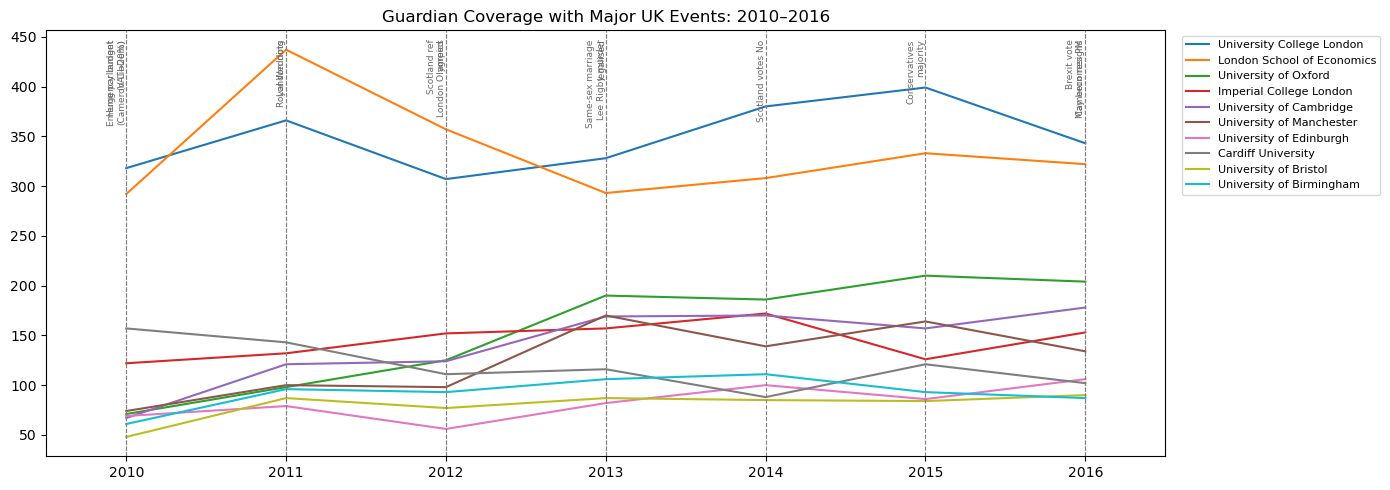

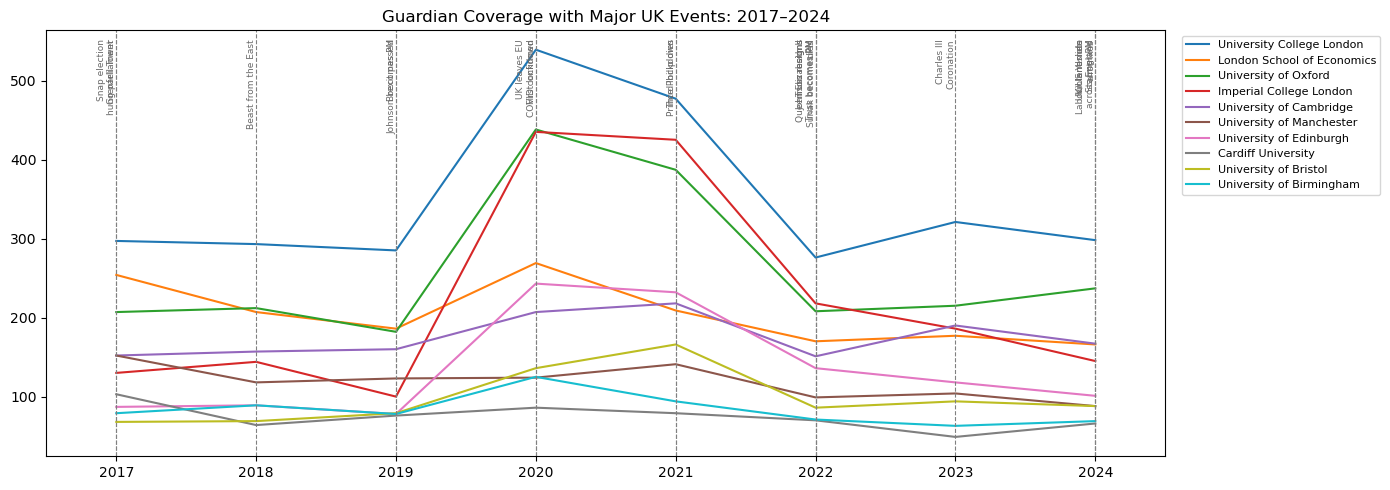

In [12]:
import matplotlib.ticker as ticker

uni_order = df['university'].value_counts().index.tolist()
palette = sns.color_palette('tab10', n_colors=len(uni_order))
colour_map = dict(zip(uni_order, palette))

events_1 = events[events['date'].dt.year < 2017]
events_2 = events[events['date'].dt.year >= 2017]

for period, subset_counts, subset_events, xlim in [
    ('2010–2016', counts[counts['year'] < 2017], events_1, (2009.5, 2016.5)),
    ('2017–2024', counts[counts['year'] >= 2017], events_2, (2016.5, 2024.5))
]:
    fig, ax = plt.subplots(figsize=(14, 5))

    for uni in uni_order:
        subset = subset_counts[subset_counts['university'] == uni]
        ax.plot(subset['year'], subset['article_count'], label=uni, color=colour_map[uni])

    for _, row in subset_events.iterrows():
        ax.axvline(x=row['date'].year, color='grey', linestyle='--', linewidth=0.8)
        ax.text(row['date'].year, ax.get_ylim()[1] * 0.98, row['event_name'],
                rotation=90, fontsize=6.5, va='top', ha='right', color='dimgrey')

    ax.set_title(f'Guardian Coverage with Major UK Events: {period}')
    ax.set_xlim(xlim)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

From this overlay of major social events and the article counts on universities, we found that not every major event, like the influential Brexit, has a significant impact on the number of articles. Most of the slight ups and downs and crossovers of the lines are not reflective enough for social events. This is reasonable and also informative from some perspectives. First, this doesn't mean that social events are unrelevant to media coverage on universities, but shows that except for extreme situations and sudden changes, political events, economic changes, and other lasting effects are already linked with publication related to universities, and because of the fact that every month and every year there are a lot of impactful events happenning, the fluctiations on universities-related articles are not huge. Second, the media coverage on universities, especially in terms of the number of articles, might be impacted by the longer-term influence of those social events and other factors (i.e., college-scale news and policies); therefore, overlaying the timelines and the number of articles doesn't tell an obvious trend.

However, as we noted before, the number of articles of most of the universities, especially more famous universities, increased a lot in 2020 and remained at a relatively high level in 2021. This shows both the immediate and lasting impact of the COVID-19 pandemic on UK education and university life.

Also, we noted that, in 2021, LSE's media coverage was higher than that of all other selected universities. In 2021, In 2011, Riots happened. Firstly, LSE is a prestigious school in social science, scholars and researchers pay attention to topics like social inequality, police power, and public relations, and therefore it was heavily involved in analyzing and researching the England riots in August 2011. Second, it's located in London, where the 2011 England riots happened (similarly, we found that the increase of media coverage on UCL increased in 2011 as well, which might also be partially explained by its location, the Riots' direct impact, and related research). 

3. Analysis on the changes of data

We have observed a big picture of trends in the number of articles related to universities, and we have analysed factors and social events that caused these changes. Now we will demonstrate the movements of data and trends.

3.1 Bar charts -- showing the increases and decreases comparatively

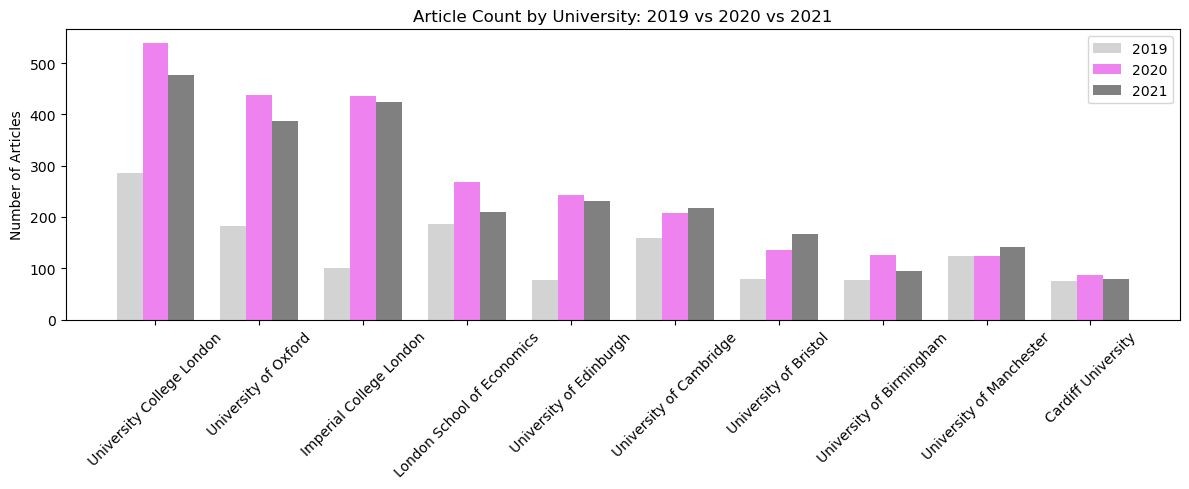

In [21]:
import matplotlib.pyplot as plt

years = [2019, 2020, 2021]
colors = ['lightgrey', 'violet', 'grey']
width = 0.25

uni_order = counts[counts['year'] == 2020].sort_values('article_count', ascending=False)['university'].tolist()

fig, ax = plt.subplots(figsize=(12, 5))

for i, (year, color) in enumerate(zip(years, colors)):
    subset = counts[counts['year'] == year].set_index('university')
    values = [subset.loc[u, 'article_count'] if u in subset.index else 0 for u in uni_order]
    x = [j + i * width for j in range(len(uni_order))]
    ax.bar(x, values, width=width, label=str(year), color=color)

ax.set_xticks([j + width for j in range(len(uni_order))])
ax.set_xticklabels(uni_order, rotation=45)
ax.set_title('Article Count by University: 2019 vs 2020 vs 2021')
ax.set_ylabel('Number of Articles')
ax.legend()
plt.tight_layout()
plt.show()

From the above bar chart, we found that most of the universities experienced an increase in the number of articles related to them, and in some cases, the increases are close to double and triple. In general, the larger the total amount of media coverage is, the more obvious the increase is. The last 5 universities showed less representative and less obvious increasing trends from 2019 to 2020 and 2021 compared to the top 5 universities. This internal difference could be explained by the size and scale of both the university itself and the amount of media reports related to it.

4. Conclusion

From analysing the data on a time-series basis and with the aid of visualisation, we have observed both obvious patterns and changes in media coverage on universities with respect to impactful social events, and less obvious patterns that are not directly reflective of outside factors but explain some embedded relationships between the UK higher education system and the wider social life.